### Step 1: Import API keys and libraries

In [ ]:
import os
import json
import gradio as gr
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import Markdown, display
import uuid
from pathlib import Path
import chromadb
from document_chunker import DocumentChunker
import random

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY is None:
    raise Exception("API_KEY is missing.")

/workspaces/AIchallenge/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 2: Simple RAG

In [ ]:


# 1. Load the documents (every .txt sitting next to this script)
filenames = sorted(Path(".").glob("*.txt"))
docs = [(p.read_text(), {"source": p.name}) for p in filenames]

# 2. Chunk them all into one flat list, metadata preserved per chunk
chunker = DocumentChunker(chunk_size=800, chunk_overlap=100)
all_chunks = chunker.split_many(docs)

# 3. Store in Chroma (lets Chroma embed with its default model)
client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_or_create_collection(name="documents")

In [4]:
def display_chunks_md(chunks, n=None):
    """Render chunks as markdown. If n is given, only show the first n."""
    subset = chunks[:n] if n is not None else chunks
    for c in subset:
        md = (
            f"### Chunk {c.index}  \n"
            f"*chars {c.start_char}–{c.end_char} · ~{c.token_estimate} tokens*  \n"
            f"*metadata:* `{c.metadata}`\n\n"
            f"> {c.text.strip().replace(chr(10), chr(10) + '> ')}\n\n"
            f"---"
        )
        display(Markdown(md))
    if n is not None and n < len(chunks):
        display(Markdown(f"*...{len(chunks) - n} more chunks not shown*"))

# display_chunks_md(chunks, n=5)
from pprint import pprint
pprint(all_chunks)


[Chunk(text='Missouri University of Science and Technology\n'
            'Rolla, Missouri\n'
            ' \n'
            'Missouri University of Science and Technology—commonly known as '
            'Missouri S&T—is a public research university in Rolla, Missouri, '
            'and part of the four-campus University of Missouri System. With '
            'approximately 7,000 students, it is widely regarded as one of the '
            "nation's leading technological universities, known for rigorous "
            'academics, strong research programs, and exceptional graduate '
            'career outcomes.\n'
            ' \n'
            'HISTORY\n'
            ' \n',
       index=0,
       start_char=0,
       end_char=478,
       metadata={'chunk_index': 0, 'source': 'college-university.txt'}),
 Chunk(text='rigorous academics, strong research programs, and exceptional '
            'graduate career outcomes.\n'
            ' \n'
            'HISTORY\n'
            ' \n'
         

In [ ]:
# Assign deterministic UUIDs to each chunk based on source document and chunk index, so we can upsert without creating duplicates
#import uuid

### You can change the namespace to any fixed UUID, but if you do, you'll need to clear the collection to avoid duplicates, since the same chunk will get a different UUID with a different namespace. So we use a fixed namespace and keep it constant to allow upserts without duplicates.  See the following quoted code for how to mint a namespace if you want to use a different one.

"""
# Run this ONCE, in a throwaway cell, to mint your namespace:
import uuid
print(uuid.uuid4())
"""

NAMESPACE = uuid.NAMESPACE_DNS   # any fixed namespace works; just keep it constant

collection.upsert(
    ids=[
        str(uuid.uuid5(NAMESPACE, f"{c.metadata['source']}::{c.metadata['chunk_index']}"))
        for c in all_chunks
    ],
    documents=[c.text for c in all_chunks],
    metadatas=[c.metadata for c in all_chunks],
)

print(f"{len(all_chunks)} chunks from {len(filenames)} documents")
print(f"collection now holds {collection.count()} chunks")

2026-05-30 17:10:11.928549574 [W:onnxruntime:Default, device_discovery.cc:133 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/PNP0A03:00/device:07/VMBUS:01/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename "5620e0c7-8062-4dce-aeb7-520c7ef76171" did not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+


20 chunks from 4 documents
collection now holds 20 chunks


Cluster 0: Life and Career Journey of Jared Gavin
Cluster 1: Missouri University of Science and Technology overview
Cluster 2: Regional Public University Academic Programs and History


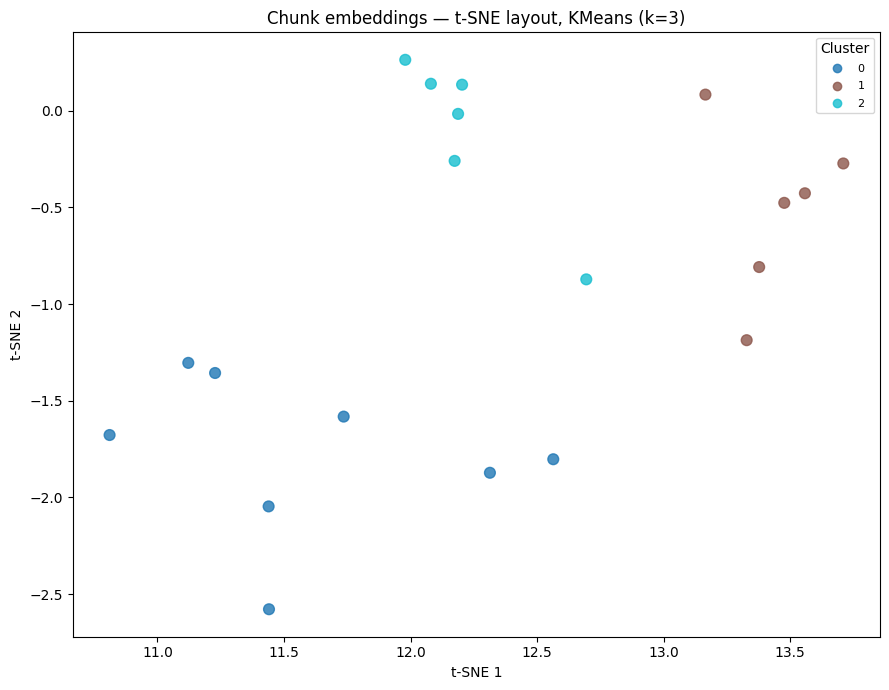

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ---- adjustable knob ----
n_clusters = 3          # <- change this to set the number of clusters
# -------------------------

# 1. Pull embeddings out of Chroma (must request them explicitly)
data = collection.get(include=["embeddings", "metadatas"])
embeddings = np.array(data["embeddings"])           # (70, 384)
sources = [m["source"] for m in data["metadatas"]]

# 2. KMeans on the ORIGINAL high-dim embeddings
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

# 3. t-SNE down to 2-D purely for plotting
coords = TSNE(
    n_components=2,
    perplexity=15,        # must be < number of points
    random_state=42,
    init="pca",
).fit_transform(embeddings)

# 4. Scatter, colored by KMeans cluster
plt.figure(figsize=(9, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1],
                      c=labels, cmap="tab10", alpha=0.8, s=60)
plt.legend(*scatter.legend_elements(), title="Cluster", fontsize=8)
plt.title(f"Chunk embeddings — t-SNE layout, KMeans (k={n_clusters})")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout()
#plt.show()

# Plotly hover labels
import plotly.express as px

fig = px.scatter(
    x=coords[:, 0], y=coords[:, 1],
    color=labels.astype(str),
    hover_data={
        "id": data["ids"],
        "chunk_index": [m["chunk_index"] for m in data["metadatas"]],
        "source": [m["source"] for m in data["metadatas"]],
    },
    title="Chunk embeddings (hover for id)",
)
fig.update_traces(marker=dict(size=9, opacity=0.8))
fig.show()

# Describe each cluster by the most common source document among its chunks using a prompt to GPT-4.1-mini
data = collection.get(include=["embeddings", "documents", "metadatas"])
embeddings = np.array(data["embeddings"])
docs = data["documents"]
labels = kmeans.fit_predict(embeddings) 


client = OpenAI(api_key=OPENAI_API_KEY)

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

k = labels.max() + 1

# Pool each cluster's chunks into one "super-document"
for c in range(k):
    sample = [d for d, lab in zip(docs, labels) if lab == c][:5]
    prompt = ("Give a short 5–8 word label for the common theme of these excerpts:\n\n"
              + "\n---\n".join(sample))
    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}],
    )
    print(f"Cluster {c}: {resp.choices[0].message.content}")

In [7]:
tools = []

In [8]:
pushover_user = os.getenv("PUSHOEVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

import requests 
def send_notification(message: str):
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)
    
send_notification_function = {
    "name": "send_notification",
    "description": "Send a notification to the real-world version of you via Pushover.",
    "parameters": {
        "type": "object",
        "properties": {
            "message": {
                "type": "string",
                "description": "The message to send as a notification."
            }
        },
        "required": ["message"]
    }
}

tools.append({"type": "function", "function":send_notification_function})

In [ ]:


def dice_roll():
    result = random.randint(1, 6)
    return result

roll_dice_function = {
    "name": "dice_roll",
    "description": "Simulates rolling a single six-sided die and returns the result.  Use this when the user wants to roll a die for games, dcisions, or randcom numbers.",
    "parameters": {
        "type": "object",
        "properties": {},
        "required": []
    }
}

tools.append({"type": "function", "function": roll_dice_function})

In [10]:
def handle_tool_call(tool_calls):
    tool_results = []
    for tool_call in tool_calls:
        function_name = tool_call.function.name
        args = json.loads(tool_call.function.arguments)
        
        if function_name == "send_notification":
            send_notification(args["message"])
            content = f"Notification sent with message: {args['message']}"
        elif function_name == "dice_roll":
            content = f"Die rolled and the result is: {dice_roll()}"
        else:
            content = f"Unknown tool: {function_name}"
        
        tool_call_result = {
            "role": "tool",
            "content": content,
            "tool_call_id": tool_call.id
        }
        
        tool_results.append(tool_call_result)
        
    return tool_results

### Step 6: Test Retrieval

In [12]:
test_query = "pets"
test_query2 = "college life"

queries = [test_query, test_query2]

results = collection.query(
    query_texts=[test_query, test_query2],
    n_results=3,
)

for q_idx, query in enumerate(queries):
    print(f"Query: {query}")
    print("Retrieved Chunks:")
    docs = results["documents"][q_idx]
    metas = results["metadatas"][q_idx]
    for doc, meta in zip(docs, metas):
        print(f"[{meta['source']}] chunk {meta['chunk_index']}:\n{doc}\n")
    print("-" * 60)


Query: pets
Retrieved Chunks:
[personal.txt] chunk 2:
remiere Video, Burlington Inc., Coca Cola Enterprises, and the UAM Science Center turoring lab.
   
   Jared has a son name Russell Desley Gavin who's middle name is after his great grandfather Desley.  His wifes name is Linzy Jo Gavin and her maiden name was Forrest.  His friends are Derrek, Mark, Mrs. Smith, Bae, Josh and Amanda McKeiver.  He has 8 dogs named Cindy, Josie, Alfred, Bessie, Pepper, Lemon, Tootsie, and Willy.  He has serveral cats named Rosieta, Mr. Kitty, Mrs. Kitty, Trey Kitty, Greyworm, Quientin, Oreo, and Tormund.  He also has a rabbit named Shadow who is a silver-fox rabbit who likes to eat kale and berry flavored yougurt bites.  Josie like to play tug-o-war.  Bessie is a stage 5 clinger.  Lemon has a pretty smile.  Cindy is a retired military dog who likes to yat yat and patrol.

[personal.txt] chunk 1:
erole, chicken and dumplings, and frito chili cheese pies which were some of his favorite meals.",

During hi

### Step 7: Function to Process the Conversation Turn (with RAG)

In [13]:
system_message = "You are Jared Gavin and you always respond in a Captain Jack Sparrow style but you are NOT captain jack sparrow."

In [24]:
# openai_client is the single OpenAI client used throughout the agent loop
openai_client = OpenAI(api_key=OPENAI_API_KEY)


def respond_ai(message, history):
    # ── 1. RAG retrieval ────────────────────────────────────────────────────
    #    query_texts lets Chroma use the registered OpenAI embedding function
    #    (text-embedding-3-small) so vectors are always in the same space.
    results = collection.query(
        query_texts=[message],
        n_results=3,
    )

    retrieved_docs   = results["documents"][0]
    retrieved_metas  = results["metadatas"][0]
    context = "\n---\n".join(
        f"[{m['source']}] {d}" for d, m in zip(retrieved_docs, retrieved_metas)
    )

    system_message_enhanced = system_message + "\n\nContext:\n" + context

    # ── 2. Build initial message list ───────────────────────────────────────
    messages = (
        [{"role": "system", "content": system_message_enhanced}]
        + history
        + [{"role": "user", "content": message}]
    )

    # ── 3. Agent loop: keep going until the model stops calling tools ───────
    while True:
        response = openai_client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=messages,
            tools=tools,
        )

        choice = response.choices[0]

        # No tool call – model is done; return its text reply
        if choice.finish_reason != "tool_calls":
            return choice.message.content

        # Tool call(s) – append assistant message then tool results to history
        assistant_msg = choice.message
        messages.append(assistant_msg)                       # assistant turn

        tool_results = handle_tool_call(assistant_msg.tool_calls)
        messages.extend(tool_results)                        # tool turn(s)
        # Loop back: model will read tool results and continue



In [25]:
gr.ChatInterface(fn=respond_ai).launch(inbrowser=True, inline=False)

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.
